04_first_spike_rule.ipynb

first spike rule: we keep only the first spike in each burst

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Robust project-root finder
cwd = Path.cwd()
print("Current working directory:", cwd)

if (cwd / "src").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "src").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError(
        "Could not find src folder. Make sure this notebook is inside the project folder."
    )

sys.path.insert(0, str(PROJECT_ROOT))
print("Using project root:", PROJECT_ROOT)

from src.inputs import (
    make_burst_sequence,
    first_spike_filter,
    burst_overlap_duration,
    g_AMPA_vector,
    g_NMDA_vector,
)

from src.dendrite import (
    simulate_dendrite,
    score_detection,
)

Current working directory: c:\Users\books\Desktop\EE 207\Neuromorphics-Dendrite-Invariance\notebooks
Using project root: c:\Users\books\Desktop\EE 207\Neuromorphics-Dendrite-Invariance


In [13]:
# Dendrite setup
n_segments = 12
sequence_segments = [5, 6, 7, 8]

T = 120.0
dt = 0.02

# Intrinsic dendrite parameters
G_NMDA = 20.0
G_KIR = 20.0
G_ax = 1.0

# Synaptic scaling parameters
# These are used if your updated simulate_dendrite supports them.
G_AMPA = 1.0
G_NMDA_syn = 1.0

# Input timing
start_time = 10.0
weight = 1.0

# Burst parameters
burst_len = 3
isi_ms = 2.0

# Severe-overlap case
target_overlap_ms = 3.5
burst_span_ms = (burst_len - 1) * isi_ms
overlap_onset_step_ms = burst_span_ms - target_overlap_ms

print("burst span:", burst_span_ms, "ms")
print("target overlap:", target_overlap_ms, "ms")
print("overlap onset step:", overlap_onset_step_ms, "ms")
print(
    "actual overlap:",
    burst_overlap_duration(overlap_onset_step_ms, burst_len, isi_ms),
    "ms",
)

# Shared plot axes
xlim_raster = (8, 20)
xlim_voltage = (8, 35)
xlim_ampa = (8, 25)
xlim_nmda = (8, 80)

ylim_voltage = (-1.1, 1.1)
ylim_ampa = (0, 3)
ylim_nmda = (0, 3)

burst span: 4.0 ms
target overlap: 3.5 ms
overlap onset step: 0.5 ms
actual overlap: 3.5 ms


In [3]:
def plot_input_raster(
    raster: dict[int, list[float]],
    title: str,
    xlim: tuple[float, float] | None = None,
) -> None:
    """Plot input spike times for each segment."""
    plt.figure(figsize=(9, 2.8))

    sorted_segments = sorted(raster.keys())
    for y, seg in enumerate(sorted_segments):
        plt.vlines(raster[seg], y - 0.35, y + 0.35)

    plt.yticks(range(len(sorted_segments)), [f"seg {seg}" for seg in sorted_segments])
    plt.xlabel("time (ms)")
    plt.ylabel("input segment")
    plt.title(title)

    if xlim is not None:
        plt.xlim(*xlim)

    plt.tight_layout()
    plt.show()


def plot_voltage_traces_shared(
    times,
    V_hist,
    segments_to_plot,
    title,
    xlim=None,
    ylim=None,
):
    """Voltage traces with shared axes."""
    plt.figure(figsize=(9, 4))

    for seg in segments_to_plot:
        plt.plot(times, V_hist[:, int(seg)], label=f"segment {seg}")

    plt.axhline(0, linestyle="--", linewidth=1, label="threshold = 0")

    if xlim is not None:
        plt.xlim(*xlim)

    if ylim is not None:
        plt.ylim(*ylim)

    plt.xlabel("time (ms)")
    plt.ylabel("voltage")
    plt.title(title)
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.show()


def compute_conductance_history(times, n_segments, events, conductance_fn):
    """Compute conductance matrix over time."""
    G = np.zeros((len(times), n_segments))

    for i, t in enumerate(times):
        G[i, :] = conductance_fn(float(t), n_segments, events)

    return G


def plot_conductance_history(
    times,
    G_hist,
    segments,
    title,
    ylabel,
    xlim=None,
    ylim=None,
):
    """Plot conductance traces with shared axes."""
    plt.figure(figsize=(9, 4))

    for seg in segments:
        plt.plot(times, G_hist[:, int(seg)], label=f"segment {seg}")

    if xlim is not None:
        plt.xlim(*xlim)

    if ylim is not None:
        plt.ylim(*ylim)

    plt.xlabel("time (ms)")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.show()


def plot_before_after_same_segment(
    times,
    G_before,
    G_after,
    segment,
    title,
    ylabel,
    xlim=None,
    ylim=None,
):
    """Overlay before/after conductance for one segment."""
    plt.figure(figsize=(9, 4))

    plt.plot(times, G_before[:, segment], label="raw overlap")
    plt.plot(times, G_after[:, segment], label="first-spike filtered")

    if xlim is not None:
        plt.xlim(*xlim)

    if ylim is not None:
        plt.ylim(*ylim)

    plt.xlabel("time (ms)")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [4]:
def run_simulation(events):
    """Run dendrite simulation with compatibility for old/new simulate_dendrite."""
    try:
        return simulate_dendrite(
            n_segments=n_segments,
            T=T,
            dt=dt,
            G_NMDA=G_NMDA,
            G_KIR=G_KIR,
            G_ax=G_ax,
            G_AMPA=G_AMPA,
            G_NMDA_syn=G_NMDA_syn,
            ampa_events=events,
        )
    except TypeError:
        return simulate_dendrite(
            n_segments=n_segments,
            T=T,
            dt=dt,
            G_NMDA=G_NMDA,
            G_KIR=G_KIR,
            G_ax=G_ax,
            ampa_events=events,
        )


def activation_times(times, V_hist, segments, threshold=0.0):
    """Return first threshold-crossing time for each segment."""
    out = {}

    for seg in segments:
        crossed = np.where(V_hist[:, int(seg)] >= threshold)[0]
        out[int(seg)] = float(times[crossed[0]]) if len(crossed) else np.nan

    return out


def score_sequence_order(
    times,
    V_hist,
    sequence_segments,
    threshold=0.0,
    min_step_separation_ms=1.0,
):
    """
    Score not just whether all segments reached plateau,
    but whether they crossed threshold with enough temporal separation.
    """
    score = score_detection(
        times,
        V_hist,
        sequence_segments=sequence_segments,
        threshold=threshold,
    )

    act = activation_times(
        times,
        V_hist,
        sequence_segments,
        threshold=threshold,
    )

    act_values = [act[int(seg)] for seg in sequence_segments]
    all_detected = all(np.isfinite(x) for x in act_values)

    if all_detected:
        step_separations = np.diff(act_values)
        separated = bool(np.all(step_separations >= min_step_separation_ms))
    else:
        step_separations = np.array([])
        separated = False

    score["activation_times"] = act
    score["step_separations"] = step_separations
    score["separated"] = separated
    score["sequence_success"] = bool(score["success"] and separated)

    return score


def print_sequence_score(name, score):
    print("=" * 70)
    print(name)
    print("=" * 70)
    print("regular success:", score["success"])
    print("sequence success:", score["sequence_success"])
    print("all detected:", score["all_detected"])
    print("ordered:", score["ordered"])
    print("separated:", score["separated"])
    print("final high:", score["final_high"])
    print("final voltage:", round(score["final_voltage"], 3))
    print("activation times:", score["activation_times"])
    print("step separations:", np.round(score["step_separations"], 3))

In [6]:
# Raw severe-overlap burst input
raw_events, raw_raster = make_burst_sequence(
    sequence_segments=sequence_segments,
    start_time=start_time,
    onset_step_ms=overlap_onset_step_ms,
    burst_len=burst_len,
    isi_ms=isi_ms,
    weight=weight,
)

# First-spike rule:
# keep only the first spike of each burst
filtered_events = first_spike_filter(raw_events)

# Rebuild raster from filtered events
filtered_raster = {}
for event in filtered_events:
    seg = int(event["segment"])
    t = float(event["time"])
    filtered_raster.setdefault(seg, []).append(t)

print("Number of raw events:", len(raw_events))
print("Number of filtered events:", len(filtered_events))

print("\nRaw raster:")
print(raw_raster)

print("\nFiltered raster:")
print(filtered_raster)

Number of raw events: 12
Number of filtered events: 4

Raw raster:
{5: [10.0, 12.0, 14.0], 6: [10.5, 12.5, 14.5], 7: [11.0, 13.0, 15.0], 8: [11.5, 13.5, 15.5]}

Filtered raster:
{5: [10.0], 6: [10.5], 7: [11.0], 8: [11.5]}


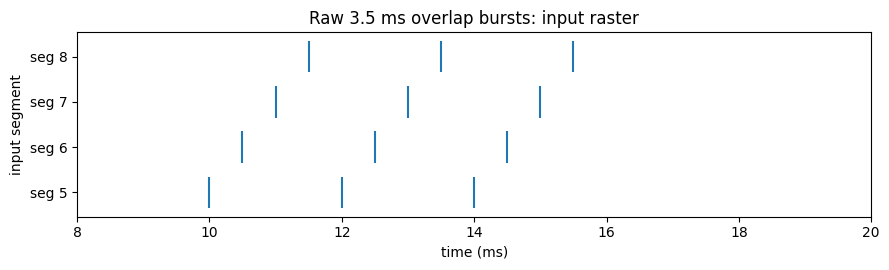

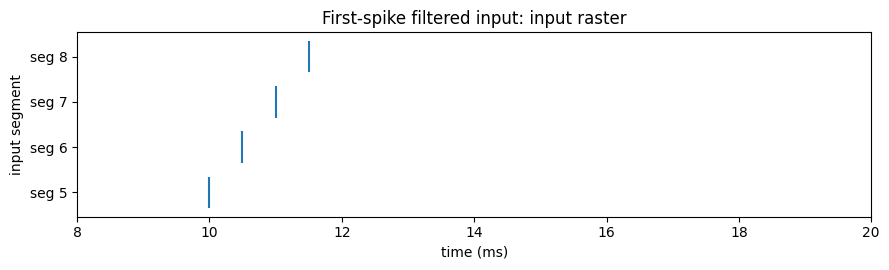

In [ ]:
plot_input_raster(
    raw_raster,
    "Raw 3.5 ms overlap bursts: input",
    xlim=xlim_raster,
)

plot_input_raster(
    filtered_raster,
    "First-spike filtered input",
    xlim=xlim_raster,
)

test the failure case w first spike rule

In [8]:
times_raw, V_raw = run_simulation(raw_events)
times_filtered, V_filtered = run_simulation(filtered_events)

score_raw = score_sequence_order(
    times_raw,
    V_raw,
    sequence_segments=sequence_segments,
    threshold=0.0,
    min_step_separation_ms=1.0,
)

score_filtered = score_sequence_order(
    times_filtered,
    V_filtered,
    sequence_segments=sequence_segments,
    threshold=0.0,
    min_step_separation_ms=1.0,
)

print_sequence_score("Raw 3.5 ms overlap bursts", score_raw)
print()
print_sequence_score("First-spike filtered input", score_filtered)

Raw 3.5 ms overlap bursts
regular success: True
sequence success: False
all detected: True
ordered: True
separated: False
final high: True
final voltage: 0.914
activation times: {5: 12.6, 6: 13.26, 7: 13.84, 8: 14.44}
step separations: [0.66 0.58 0.6 ]

First-spike filtered input
regular success: False
sequence success: False
all detected: False
ordered: False
separated: False
final high: False
final voltage: -0.879
activation times: {5: 13.02, 6: 14.24, 7: 15.66, 8: nan}
step separations: []


compare raw vs. filtered results

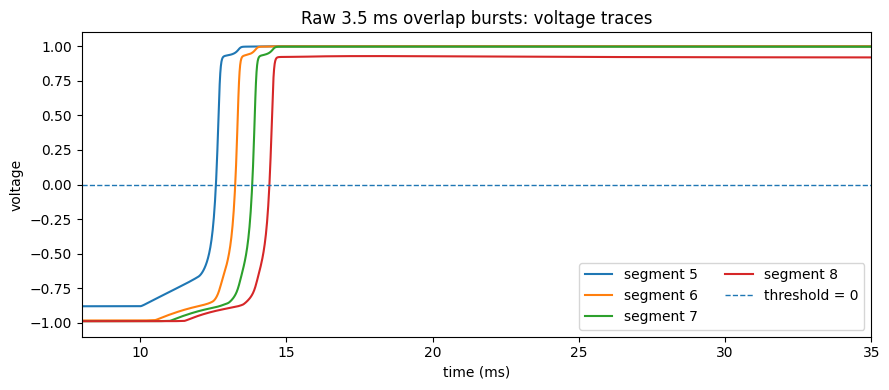

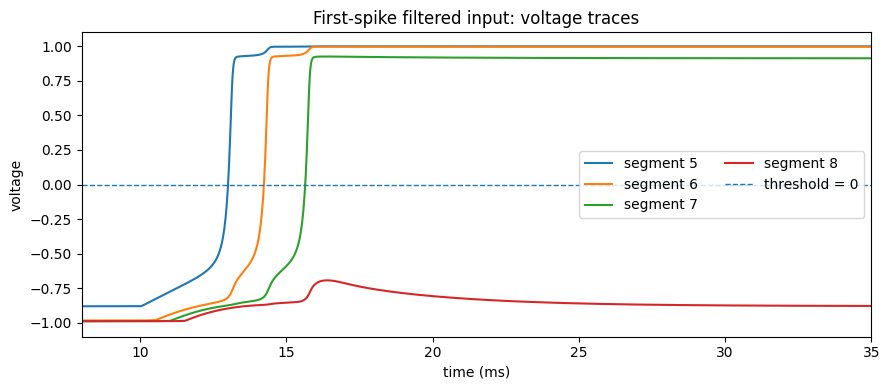

In [9]:
plot_voltage_traces_shared(
    times_raw,
    V_raw,
    sequence_segments,
    title="Raw 3.5 ms overlap bursts: voltage traces",
    xlim=xlim_voltage,
    ylim=ylim_voltage,
)

plot_voltage_traces_shared(
    times_filtered,
    V_filtered,
    sequence_segments,
    title="First-spike filtered input: voltage traces",
    xlim=xlim_voltage,
    ylim=ylim_voltage,
)

In [10]:
# Raw overlap conductances
G_ampa_raw = compute_conductance_history(
    times_raw,
    n_segments,
    raw_events,
    g_AMPA_vector,
)

G_nmda_raw = compute_conductance_history(
    times_raw,
    n_segments,
    raw_events,
    g_NMDA_vector,
)

# First-spike-filtered conductances
G_ampa_filtered = compute_conductance_history(
    times_filtered,
    n_segments,
    filtered_events,
    g_AMPA_vector,
)

G_nmda_filtered = compute_conductance_history(
    times_filtered,
    n_segments,
    filtered_events,
    g_NMDA_vector,
)

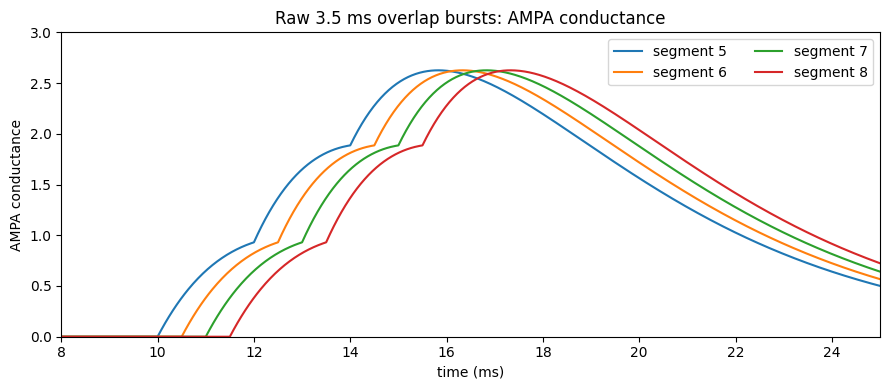

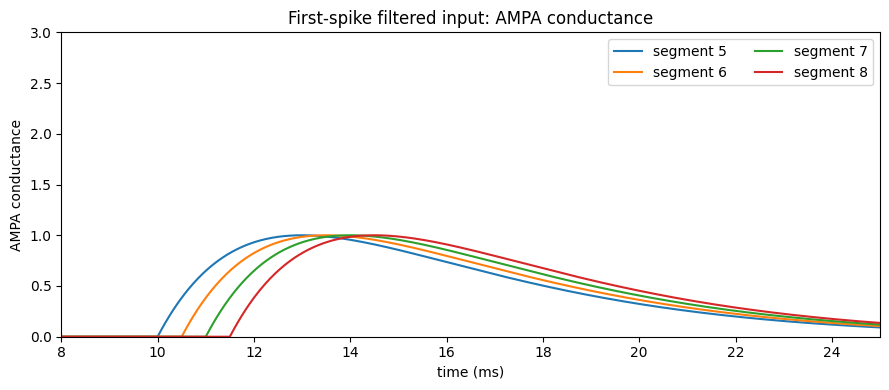

In [14]:
plot_conductance_history(
    times_raw,
    G_ampa_raw,
    sequence_segments,
    title="Raw 3.5 ms overlap bursts: AMPA conductance",
    ylabel="AMPA conductance",
    xlim=xlim_ampa,
    ylim=ylim_ampa,
)

plot_conductance_history(
    times_filtered,
    G_ampa_filtered,
    sequence_segments,
    title="First-spike filtered input: AMPA conductance",
    ylabel="AMPA conductance",
    xlim=xlim_ampa,
    ylim=ylim_ampa,
)

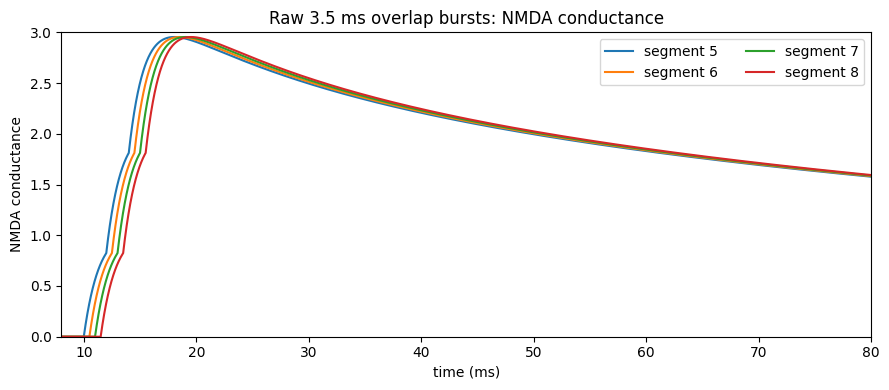

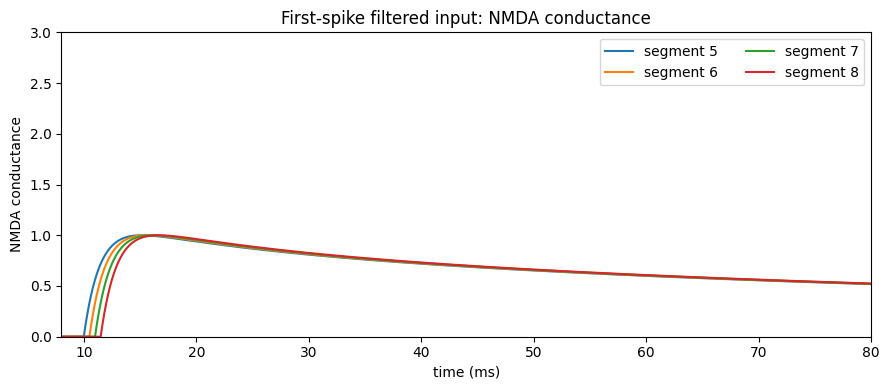

In [15]:
plot_conductance_history(
    times_raw,
    G_nmda_raw,
    sequence_segments,
    title="Raw 3.5 ms overlap bursts: NMDA conductance",
    ylabel="NMDA conductance",
    xlim=xlim_nmda,
    ylim=ylim_nmda,
)

plot_conductance_history(
    times_filtered,
    G_nmda_filtered,
    sequence_segments,
    title="First-spike filtered input: NMDA conductance",
    ylabel="NMDA conductance",
    xlim=xlim_nmda,
    ylim=ylim_nmda,
)

let's try sweeping

In [20]:
spacing_values = [0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0, 6.0, 8.0]

comparison_results = []

for onset_step_ms in spacing_values:
    raw_events_sweep, raw_raster_sweep = make_burst_sequence(
        sequence_segments=sequence_segments,
        start_time=start_time,
        onset_step_ms=onset_step_ms,
        burst_len=burst_len,
        isi_ms=isi_ms,
        weight=weight,
    )

    filtered_events_sweep = first_spike_filter(raw_events_sweep)

    # Run raw burst case
    times_raw_sweep, V_raw_sweep = run_simulation(raw_events_sweep)

    score_raw_sweep = score_sequence_order(
        times_raw_sweep,
        V_raw_sweep,
        sequence_segments=sequence_segments,
        threshold=0.0,
        min_step_separation_ms=1.0,
    )

    # Run first-spike filtered case
    times_filtered_sweep, V_filtered_sweep = run_simulation(filtered_events_sweep)

    score_filtered_sweep = score_sequence_order(
        times_filtered_sweep,
        V_filtered_sweep,
        sequence_segments=sequence_segments,
        threshold=0.0,
        min_step_separation_ms=1.0,
    )

    comparison_results.append(
        {
            "spacing_ms": onset_step_ms,
            "overlap_ms": burst_overlap_duration(onset_step_ms, burst_len, isi_ms),

            "raw_regular_success": score_raw_sweep["success"],
            "raw_sequence_success": score_raw_sweep["sequence_success"],
            "raw_final_voltage": score_raw_sweep["final_voltage"],
            "raw_activation_times": score_raw_sweep["activation_times"],
            "raw_step_separations": score_raw_sweep["step_separations"],

            "filtered_regular_success": score_filtered_sweep["success"],
            "filtered_sequence_success": score_filtered_sweep["sequence_success"],
            "filtered_final_voltage": score_filtered_sweep["final_voltage"],
            "filtered_activation_times": score_filtered_sweep["activation_times"],
            "filtered_step_separations": score_filtered_sweep["step_separations"],
        }
    )

for r in comparison_results:
    print("=" * 80)
    print("spacing:", r["spacing_ms"], "ms")
    print("burst overlap:", r["overlap_ms"], "ms")

    print("\nRAW BURSTS")
    print("regular success:", r["raw_regular_success"])
    print("sequence success:", r["raw_sequence_success"])
    print("final voltage:", round(r["raw_final_voltage"], 3))
    print("activation times:", r["raw_activation_times"])
    print("step separations:", np.round(r["raw_step_separations"], 3))

    print("\nFIRST-SPIKE FILTERED")
    print("regular success:", r["filtered_regular_success"])
    print("sequence success:", r["filtered_sequence_success"])
    print("final voltage:", round(r["filtered_final_voltage"], 3))
    print("activation times:", r["filtered_activation_times"])
    print("step separations:", np.round(r["filtered_step_separations"], 3))

spacing: 0.5 ms
burst overlap: 3.5 ms

RAW BURSTS
regular success: True
sequence success: False
final voltage: 0.914
activation times: {5: 12.6, 6: 13.26, 7: 13.84, 8: 14.44}
step separations: [0.66 0.58 0.6 ]

FIRST-SPIKE FILTERED
regular success: False
sequence success: False
final voltage: -0.879
activation times: {5: 13.02, 6: 14.24, 7: 15.66, 8: nan}
step separations: []
spacing: 1.0 ms
burst overlap: 3.0 ms

RAW BURSTS
regular success: True
sequence success: True
final voltage: 0.914
activation times: {5: 12.620000000000001, 6: 13.64, 7: 14.64, 8: 15.700000000000001}
step separations: [1.02 1.   1.06]

FIRST-SPIKE FILTERED
regular success: True
sequence success: True
final voltage: 0.911
activation times: {5: 13.1, 6: 14.44, 7: 15.700000000000001, 8: 17.66}
step separations: [1.34 1.26 1.96]
spacing: 1.5 ms
burst overlap: 2.5 ms

RAW BURSTS
regular success: True
sequence success: True
final voltage: 0.914
activation times: {5: 12.66, 6: 14.14, 7: 15.64, 8: 17.18}
step separations

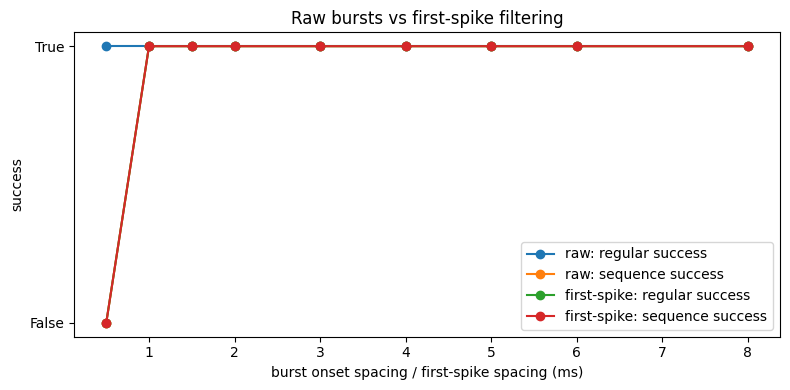

In [ ]:
spacing = np.array([r["spacing_ms"] for r in comparison_results])
overlap = np.array([r["overlap_ms"] for r in comparison_results])

raw_sequence = np.array(
    [r["raw_sequence_success"] for r in comparison_results],
    dtype=int,
)

filtered_sequence = np.array(
    [r["filtered_sequence_success"] for r in comparison_results],
    dtype=int,
)

plt.figure(figsize=(8, 4))
plt.plot(
    spacing,
    raw_sequence,
    marker="o",
    label="raw bursts",
)

plt.plot(
    spacing,
    filtered_sequence,
    marker="o",
    label="first-spike filtered",
)

plt.xlabel("burst onset spacing / first-spike spacing (ms)")
plt.ylabel("sequence success")
plt.yticks([0, 1], ["False", "True"])
plt.title("Sequence success: raw bursts vs first-spike filtering")
plt.legend()
plt.tight_layout()
plt.show()